In [1]:
import numpy as np
import imageio
import matplotlib.pyplot as plt
from skimage import color

import cv2
import common
import pylab

In [2]:
pylab.rcParams['figure.figsize'] = (6.4,4.0)
ruta = 'wall-e.jpg'
input_image = cv2.imread(ruta)

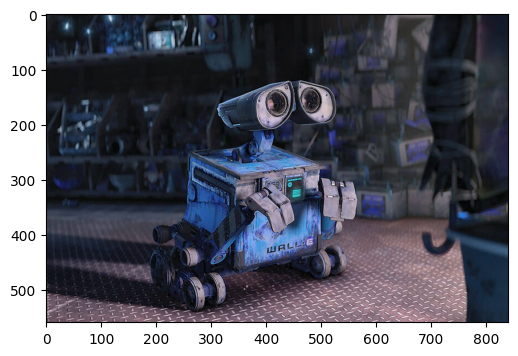

In [3]:
plt.imshow(input_image);


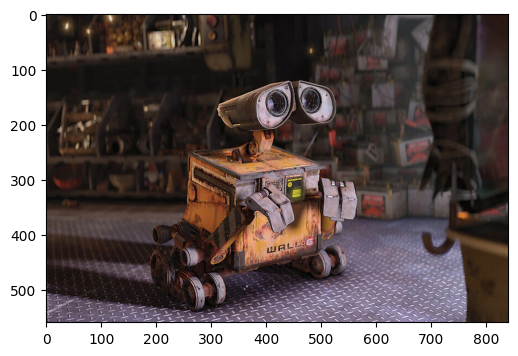

In [4]:
plt.imshow(cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB));

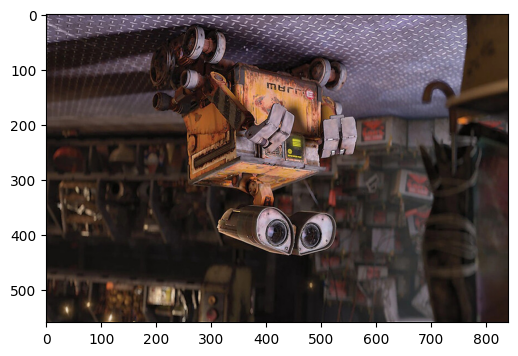

In [5]:
# Inversion vertical
flipped_image = cv2.flip(input_image,0)
plt.imshow(cv2.cvtColor(flipped_image, cv2.COLOR_BGR2RGB));

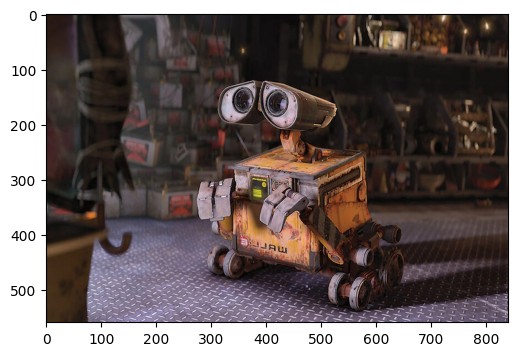

In [6]:
flip_horizontal = cv2.flip(input_image,1)
plt.imshow(cv2.cvtColor(flip_horizontal, cv2.COLOR_BGR2RGB));

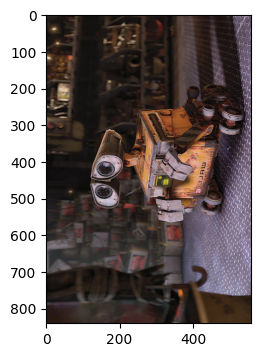

In [7]:
transpuesta = cv2.transpose(input_image)
plt.imshow(cv2.cvtColor(transpuesta, cv2.COLOR_BGR2RGB));

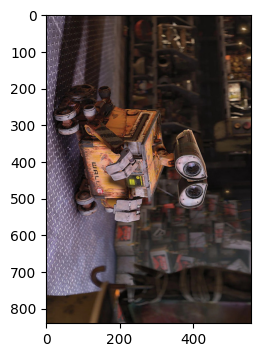

In [8]:
rotacion_90 = cv2.rotate(input_image, cv2.ROTATE_90_CLOCKWISE)
plt.imshow(cv2.cvtColor(rotacion_90, cv2.COLOR_BGR2RGB));

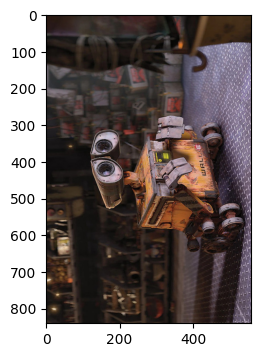

In [9]:
rotacion90_anti = cv2.rotate(input_image, cv2.ROTATE_90_COUNTERCLOCKWISE)
plt.imshow(cv2.cvtColor(rotacion90_anti, cv2.COLOR_BGR2RGB));

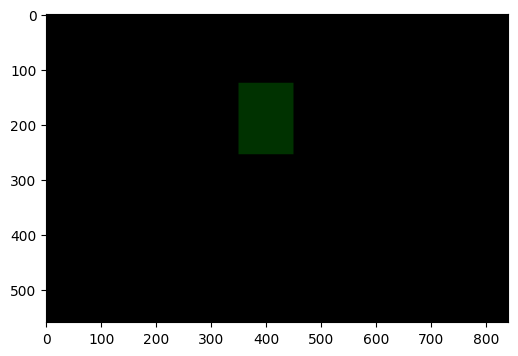

In [10]:
#Crear una matriz h, w, 3
blank_image = np.zeros((input_image.shape), np.uint8)
blank_image[125:255, 350:450, 1] = 50
plt.imshow(blank_image);

In [11]:
cv2.add(blank_image, input_image)

array([[[ 25,  26,  30],
        [ 31,  31,  37],
        [ 36,  39,  47],
        ...,
        [ 25,  29,  40],
        [ 25,  29,  40],
        [ 25,  29,  40]],

       [[ 26,  26,  32],
        [ 29,  32,  37],
        [ 35,  38,  46],
        ...,
        [ 23,  29,  42],
        [ 23,  29,  42],
        [ 23,  29,  42]],

       [[ 26,  29,  37],
        [ 29,  35,  42],
        [ 33,  40,  49],
        ...,
        [ 20,  27,  44],
        [ 20,  27,  44],
        [ 20,  27,  44]],

       ...,

       [[ 95,  80,  94],
        [ 64,  49,  63],
        [ 86,  73,  87],
        ...,
        [ 26,  47,  69],
        [ 28,  46,  69],
        [ 30,  46,  69]],

       [[105,  86, 101],
        [ 59,  42,  56],
        [ 37,  22,  36],
        ...,
        [ 25,  46,  68],
        [ 27,  45,  68],
        [ 30,  46,  69]],

       [[103,  82,  97],
        [ 83,  64,  79],
        [ 66,  49,  63],
        ...,
        [ 23,  44,  66],
        [ 26,  44,  67],
        [ 29,  45,  68]]

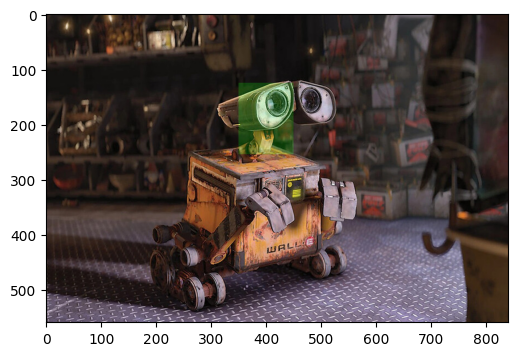

In [12]:
img_nueva = cv2.cvtColor(cv2.add(blank_image, input_image), cv2.COLOR_BGR2RGB)
plt.imshow(img_nueva);

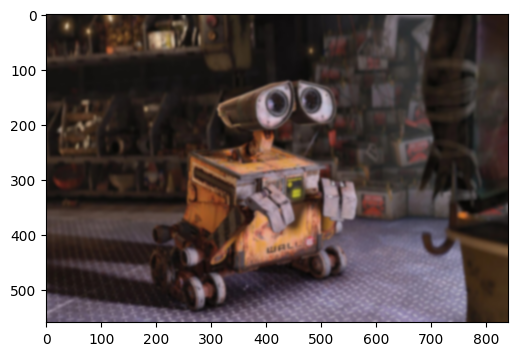

In [13]:
d = 5
img_desenfoque = cv2.GaussianBlur(input_image, (2*d+1,2*d+1), -1)
plt.imshow(cv2.cvtColor(img_desenfoque, cv2.COLOR_BGR2RGB));


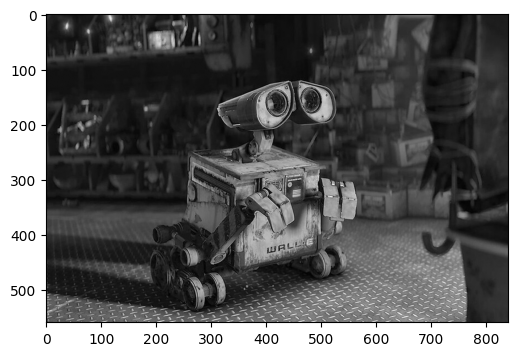

In [14]:
#Escala de grises
img_gray = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)
plt.imshow(img_gray, cmap='gray');

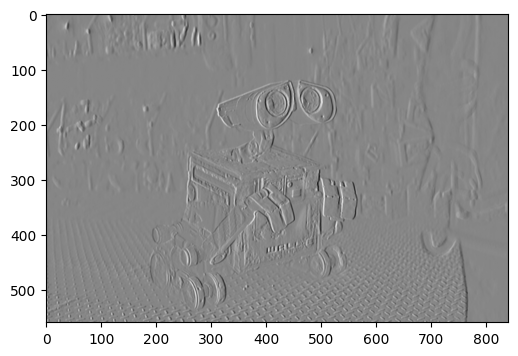

In [15]:
sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=5)
plt.imshow(sobelx, cmap='gray');

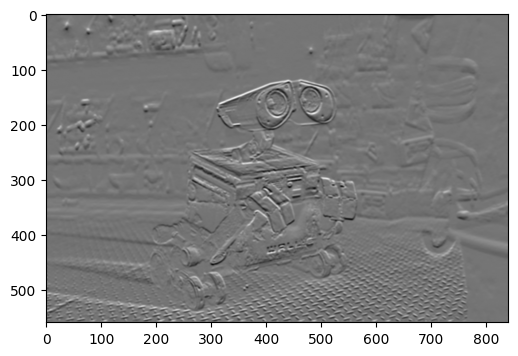

In [16]:
SobelY = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=9)
plt.imshow(SobelY, cmap='gray');

In [18]:
import tkinter as tk
from tkinter import filedialog
import cv2
import numpy as np
from PIL import Image, ImageTk

class ProcesadorDeImagenes:
    def __init__(self, root):
        self.root = root
        self.root.title("Editor OpenCV - Filtros y Transformaciones")
        # Un poco más de altura para que quepan todos los sliders cómodamente
        self.root.geometry("900x750")
        self.root.config(bg="#2b2b2b")

        self.imagen_original = None
        self.imagen_actual = None

        self.configurar_interfaz()

    def configurar_interfaz(self):
        # --- PANEL LATERAL ---
        panel_controles = tk.Frame(self.root, width=250, bg="#3c3f41", padx=10, pady=10)
        panel_controles.pack(side=tk.LEFT, fill=tk.Y)

        tk.Button(panel_controles, text="Cargar Imagen", command=self.cargar_imagen, bg="#4CAF50", fg="white", font=("Arial", 10, "bold")).pack(fill=tk.X, pady=(0, 20))

        # Sección RGB (Sliders de 0% a 200%)
        tk.Label(panel_controles, text="Canales RGB (%)", bg="#3c3f41", fg="white", font=("Arial", 10, "bold")).pack(anchor="w")
        
        self.slider_r = tk.Scale(panel_controles, from_=0, to=200, orient=tk.HORIZONTAL, label="Rojo", bg="#3c3f41", fg="#ff8888", highlightthickness=0, command=self.aplicar_transformaciones)
        self.slider_r.set(100)
        self.slider_r.pack(fill=tk.X)

        self.slider_g = tk.Scale(panel_controles, from_=0, to=200, orient=tk.HORIZONTAL, label="Verde", bg="#3c3f41", fg="#88ff88", highlightthickness=0, command=self.aplicar_transformaciones)
        self.slider_g.set(100)
        self.slider_g.pack(fill=tk.X)

        self.slider_b = tk.Scale(panel_controles, from_=0, to=200, orient=tk.HORIZONTAL, label="Azul", bg="#3c3f41", fg="#8888ff", highlightthickness=0, command=self.aplicar_transformaciones)
        self.slider_b.set(100)
        self.slider_b.pack(fill=tk.X)
        
        # Sección Blur
        tk.Label(panel_controles, text="Desenfoque (Blur)", bg="#3c3f41", fg="white", font=("Arial", 10, "bold")).pack(anchor="w", pady=(15, 0))
        self.slider_blur = tk.Scale(panel_controles, from_=0, to=30, orient=tk.HORIZONTAL, bg="#3c3f41", fg="white", highlightthickness=0, command=self.aplicar_transformaciones)
        self.slider_blur.pack(fill=tk.X)

        # Sección Ángulos
        tk.Label(panel_controles, text="Rotación (Grados)", bg="#3c3f41", fg="white", font=("Arial", 10, "bold")).pack(anchor="w", pady=(15, 0))
        self.slider_angulo = tk.Scale(panel_controles, from_=0, to=360, orient=tk.HORIZONTAL, bg="#3c3f41", fg="white", highlightthickness=0, command=self.aplicar_transformaciones)
        self.slider_angulo.pack(fill=tk.X)

        # Sección Sobel
        tk.Label(panel_controles, text="Detección de Bordes", bg="#3c3f41", fg="white", font=("Arial", 10, "bold")).pack(anchor="w", pady=(15, 0))
        tk.Button(panel_controles, text="Aplicar Sobel", command=self.aplicar_sobel, bg="#2196F3", fg="white").pack(fill=tk.X, pady=2)

        # Botón Restaurar
        tk.Button(panel_controles, text="Restaurar Original", command=self.restaurar_imagen, bg="#f44336", fg="white", font=("Arial", 10, "bold")).pack(fill=tk.X, side=tk.BOTTOM, pady=10)

        # --- ÁREA DE VISUALIZACIÓN ---
        self.panel_imagen = tk.Label(self.root, bg="#2b2b2b", text="Carga una imagen para comenzar", fg="gray", font=("Arial", 14))
        self.panel_imagen.pack(side=tk.RIGHT, expand=True, fill=tk.BOTH)

    def cargar_imagen(self):
        ruta = filedialog.askopenfilename(title="Selecciona una imagen", filetypes=[("Imágenes", "*.jpg *.jpeg *.png *.bmp")])
        if len(ruta) > 0:
            self.imagen_original = cv2.imread(ruta)
            
            alto, ancho = self.imagen_original.shape[:2]
            max_dim = 600
            if max(alto, ancho) > max_dim:
                escala = max_dim / max(alto, ancho)
                self.imagen_original = cv2.resize(self.imagen_original, (int(ancho * escala), int(alto * escala)))

            self.restaurar_imagen()

    def mostrar_imagen(self, img_cv):
        if img_cv is None: return

        if len(img_cv.shape) == 3:
            img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
        else:
            img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_GRAY2RGB)

        img_pil = Image.fromarray(img_rgb)
        img_tk = ImageTk.PhotoImage(image=img_pil)

        self.panel_imagen.config(image=img_tk, text="")
        self.panel_imagen.image = img_tk 

    def aplicar_transformaciones(self, event=None):
        if self.imagen_original is None: return

        img = self.imagen_original.copy()

        # 1. Ajuste de Canales RGB
        # Convertimos a float32 para evitar que los valores den la vuelta (overflow) al multiplicar
        img_float = img.astype(np.float32)
        
        # Obtenemos los porcentajes de los sliders (100 = 1.0)
        # Recordar que OpenCV lee en formato BGR (Azul, Verde, Rojo)
        b_scale = self.slider_b.get() / 100.0
        g_scale = self.slider_g.get() / 100.0
        r_scale = self.slider_r.get() / 100.0

        img_float[:, :, 0] *= b_scale # Canal Azul
        img_float[:, :, 1] *= g_scale # Canal Verde
        img_float[:, :, 2] *= r_scale # Canal Rojo

        # Recortamos los valores a un máximo de 255 y volvemos al formato original de imagen (uint8)
        img = np.clip(img_float, 0, 255).astype(np.uint8)

        # 2. Aplicar Rotación
        angulo = self.slider_angulo.get()
        if angulo > 0:
            (h, w) = img.shape[:2]
            centro = (w // 2, h // 2)
            M = cv2.getRotationMatrix2D(centro, angulo, 1.0)
            img = cv2.warpAffine(img, M, (w, h))

        # 3. Aplicar Blur
        blur_val = self.slider_blur.get()
        if blur_val > 0:
            k = blur_val if blur_val % 2 != 0 else blur_val + 1
            img = cv2.GaussianBlur(img, (k, k), 0)

        self.imagen_actual = img
        self.mostrar_imagen(self.imagen_actual)

    def aplicar_sobel(self):
        if self.imagen_actual is None: return

        img_gray = cv2.cvtColor(self.imagen_actual, cv2.COLOR_BGR2GRAY)
        
        sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
        sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
        
        abs_sobel_x = cv2.convertScaleAbs(sobel_x)
        abs_sobel_y = cv2.convertScaleAbs(sobel_y)
        
        sobel_combinado = cv2.addWeighted(abs_sobel_x, 0.5, abs_sobel_y, 0.5, 0)
        
        self.mostrar_imagen(sobel_combinado)

    def restaurar_imagen(self):
        if self.imagen_original is not None:
            # Volver todos los controles a su estado por defecto
            self.slider_r.set(100)
            self.slider_g.set(100)
            self.slider_b.set(100)
            self.slider_blur.set(0)
            self.slider_angulo.set(0)
            
            self.imagen_actual = self.imagen_original.copy()
            self.mostrar_imagen(self.imagen_actual)

if __name__ == "__main__":
    root = tk.Tk()
    app = ProcesadorDeImagenes(root)
    root.mainloop()